# 04 — Preprocessing and features

**Rahnema College ML Bootcamp 1405** · Week 3 · Peyman Naseri

---

## Where we are

Two weeks ago we drew the map of a data science project — nine stages, in
[`02_data_science_pipeline.ipynb`](02_data_science_pipeline.ipynb):

> problem → collect → **clean** → **EDA** → **model** → **evaluate** → deploy → monitor → report

Last week we lived in the middle-left of that map. With NumPy, pandas and
matplotlib we did the EDA properly and touched the edges of preprocessing.
Today we finish the picture: preprocessing done seriously, features, models and
honest evaluation.

For that we need one more library, and it is the last one you need for
classical machine learning: **scikit-learn**.

## Today, in four notebooks

| | | |
|---|---|---|
| **04** (this one) | before lunch | preprocessing and features, as concepts |
| **05** | before lunch | the same thing on a real forecasting problem |
| **06** | after lunch | models, cross-validation, metrics, error analysis |
| **07** | after lunch | the real experiments, and what the numbers actually said |

The concept notebooks use a small toy dataset so nothing takes longer than a
second. The case-study notebooks use a real internal problem, and they exist to
show you that the shapes are the same — just messier and with higher stakes.

---

## 1. scikit-learn, in one page

NumPy gave us arrays. pandas gave us labelled tables. scikit-learn gives us
**one interface for every model and every transformation**, and that
consistency is the whole point of it.

Everything in the library is an *estimator*, and every estimator has the same
three or four methods:

```python
est.fit(X, y)        # learn something from the data
est.predict(X)       # models: produce an answer
est.transform(X)     # transformers: produce new columns
est.fit_transform(X) # both, in one call
```

That is it. A scaler, a one-hot encoder, a random forest, a whole preprocessing
pipeline and a grid search over ten models all expose exactly those methods.
Learn the interface once and the entire library — plus most of the third-party
ecosystem, LightGBM and XGBoost included — is already familiar.

**What it covers:** preprocessing, feature selection, classical models
(linear, trees, boosting, SVM, KNN, clustering), model selection and
cross-validation, metrics, and the plumbing to chain all of it together.

**What it does not:** deep learning (that is week 4), and anything that needs a
GPU.

The single most important consequence of the shared interface is the
`Pipeline`, which we get to in section 3 — and which is the reason this
library, rather than a folder of scripts, is what the industry uses.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
import sys
sys.path.insert(0, str(ROOT))
from bootcamp import preprocessing_sheet, pipeline_anatomy, feature_families

plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_theme(style="whitegrid", rc=plt.rcParams)
RANDOM_STATE = 3

# A small delivery-time dataset: when an order is placed, how many minutes
# until it arrives? Small enough that everything here runs instantly.
deliveries = pd.read_csv(DATA / "deliveries.csv", parse_dates=["order_time"])
print(f"{deliveries.shape[0]:,} orders, {deliveries.shape[1]} columns")
deliveries.head(3)

12,000 orders, 15 columns


,order_id,order_time,store,customer_id,courier_id,courier_type,weather,basket_size,basket_value_toman,distance_km,prep_minutes,actual_route_km,rating,tip_toman,delivery_minutes
0,510849,2025-09-01 11:16:00,Vakilabad,U02396,C0061,motorcycle,clear,7,992000,1.50,10.7,2.74,4.0,38000,15.0
1,500138,2025-09-01 11:41:00,Gohardasht,U02062,C0017,motorcycle,clear,5,1236000,1.46,6.4,1.61,4.0,0,19.1
2,501157,2025-09-01 12:33:00,Vakilabad,U02021,C0199,motorcycle,clear,5,474000,3.64,7.7,3.64,4.0,45000,26.3


---

## 2. Preprocessing: what you can do to a column

Before any of it, the two rules that make the rest safe:

**Split first.** The moment you compute anything from the full dataset — a
median to impute with, a scaler's mean, the list of categories — your test set
has touched the model and your estimate of its quality is no longer honest.

**Anything that learns goes inside the Pipeline.** If a step has to look at the
data to decide what to do, it must be re-learned on every training fold. That
is not a style preference; it is the only way to stop yourself cheating by
accident.

With those in place, here is the menu. Walk it as a checklist when you meet a
new table.

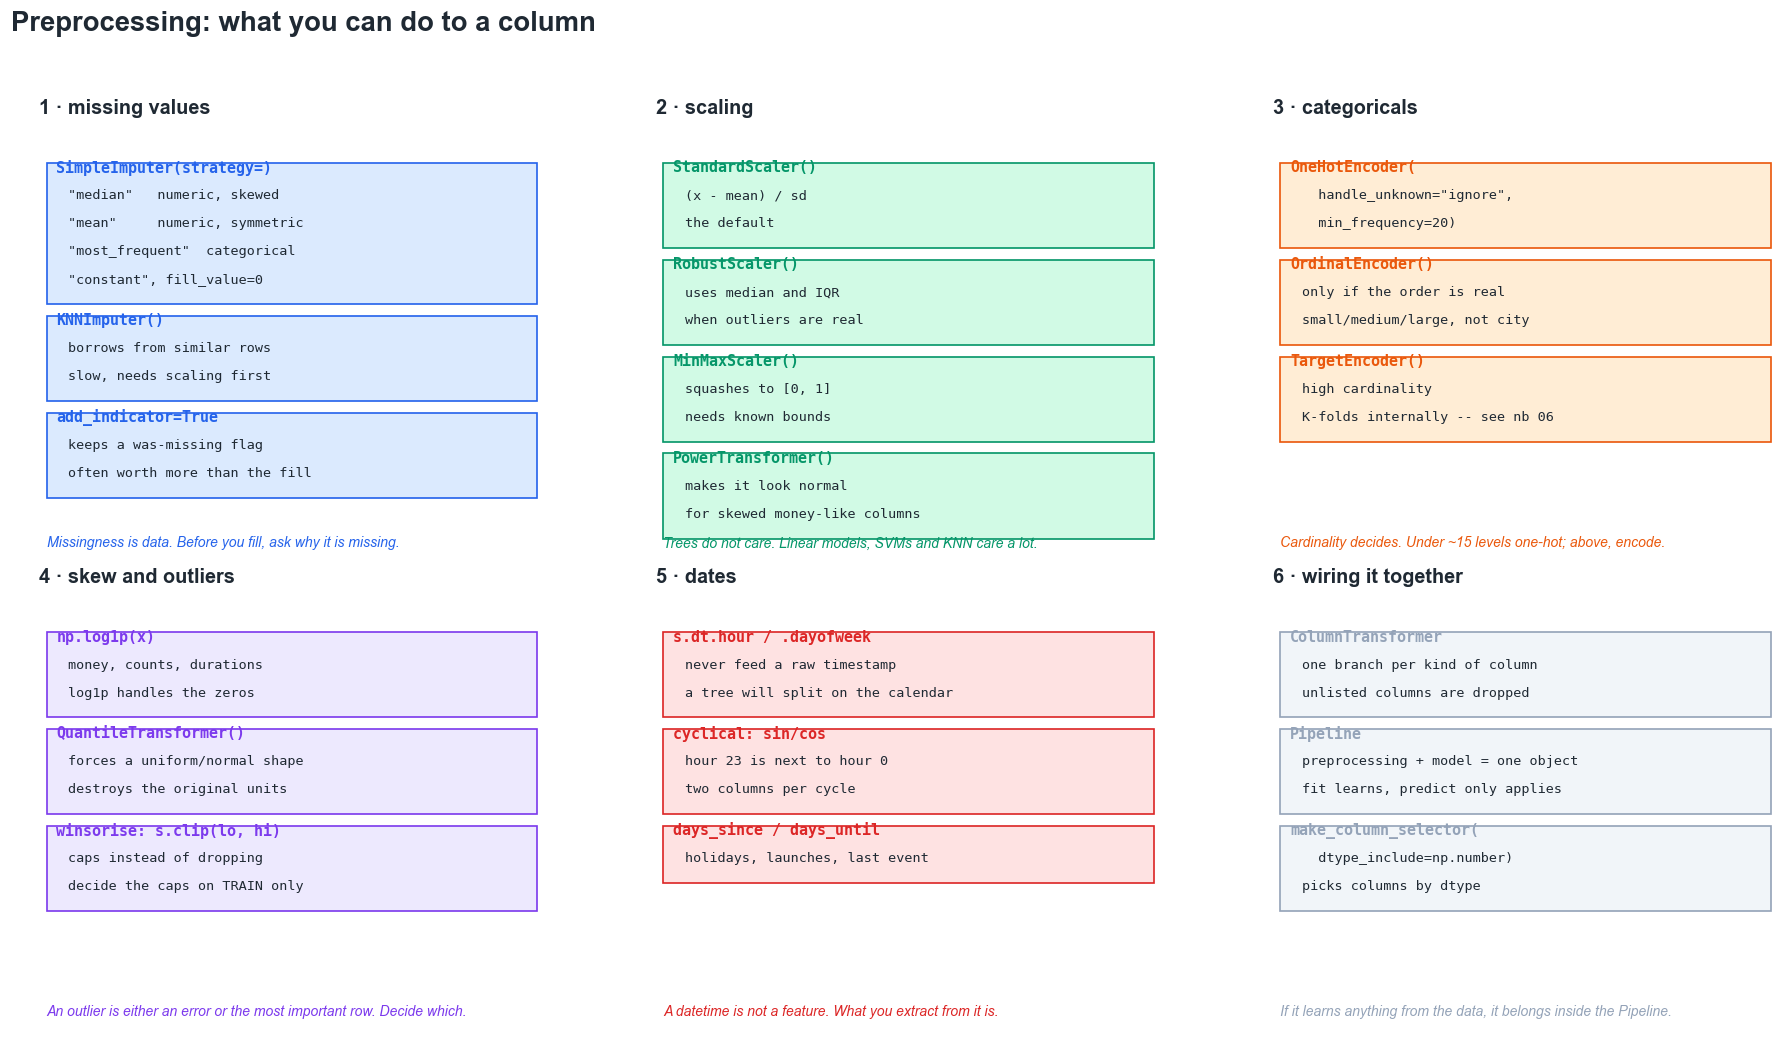

In [2]:
preprocessing_sheet();   # also assets/preprocessing_sheet.png

Four of those deserve a line of explanation you cannot fit on a diagram.

**Imputation is a modelling choice, not a cleanup step.** Filling a missing
price with the median asserts that the missingness carries no information. Very
often it does — a missing value means the sensor was offline, the form was
skipped, the product was not tracked yet. `add_indicator=True` keeps a flag
saying the value was missing, and that flag is frequently worth more than
whatever you filled in.

**Scaling matters for some models and not others.** Linear models, SVMs, KNN
and anything with a distance or a regularisation penalty need it. Trees and
tree ensembles do not care at all — they only ever compare a value to a
threshold. Keep the scaler in the pipeline anyway, so swapping the model does
not mean rewriting the preprocessing.

**One-hot is not free.** A column with 5,000 categories becomes 5,000 columns,
most of them almost always zero. `min_frequency` folds the rare ones into an
"infrequent" bucket; above a few dozen levels, target encoding is usually the
better answer, and notebook 06 shows how to do it without leaking.

**A raw timestamp is never a feature.** Hand a tree a datetime and it will
happily split on "before 14 March" — memorising the calendar instead of
learning the behaviour. What you extract from it (hour, weekday, days until a
holiday) is the feature.

In [3]:
# The menu above, on real columns. Run these, change them, break them.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, RobustScaler, OneHotEncoder,
                                   PowerTransformer)

sample = deliveries[["prep_minutes", "basket_value_toman", "weather"]].head(2000)

# 1. missing values -- note the imputer LEARNS the median in fit()
imp = SimpleImputer(strategy="median")
filled = imp.fit_transform(sample[["prep_minutes"]])
print(f"missing before: {sample['prep_minutes'].isna().sum()}"
      f"   after: {np.isnan(filled).sum()}   learned median: {imp.statistics_[0]:.1f}")

# 2. scaling -- Standard uses mean/sd, Robust uses median/IQR. On a column with
#    a long tail they disagree, and Robust is usually the one you want.
v = sample[["basket_value_toman"]]
print(f"\nstandard-scaled max: {StandardScaler().fit_transform(v).max():.1f}")
print(f"robust-scaled   max: {RobustScaler().fit_transform(v).max():.1f}")

# 3. skew -- money is always right-skewed; log1p is the cheap fix (and handles 0)
print(f"\nskew raw     : {sample['basket_value_toman'].skew():.2f}")
print(f"skew log1p   : {np.log1p(sample['basket_value_toman']).skew():.2f}")

# 4. categoricals -- handle_unknown="ignore" so an unseen category at predict
#    time becomes all-zeros instead of an exception in production at 2am.
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
out = enc.fit_transform(sample[["weather"]].fillna("missing"))
print(f"\nweather -> {out.shape[1]} columns: {list(enc.get_feature_names_out())}")

missing before: 48   after: 0   learned median: 6.6

standard-scaled max: 6.6
robust-scaled   max: 6.1

skew raw     : 1.81
skew log1p   : -0.30

weather -> 4 columns: ['weather_clear', 'weather_missing', 'weather_rain', 'weather_snow']


---

## 3. Wiring it together: ColumnTransformer and Pipeline

Numeric columns and categorical columns need different treatment, and each
treatment must be learned from the training fold only. Doing that by hand, in
the right order, every time, is where mistakes come from.

`ColumnTransformer` routes each group of columns down its own branch.
`Pipeline` glues preprocessing and model into one object with one `fit` and one
`predict`.

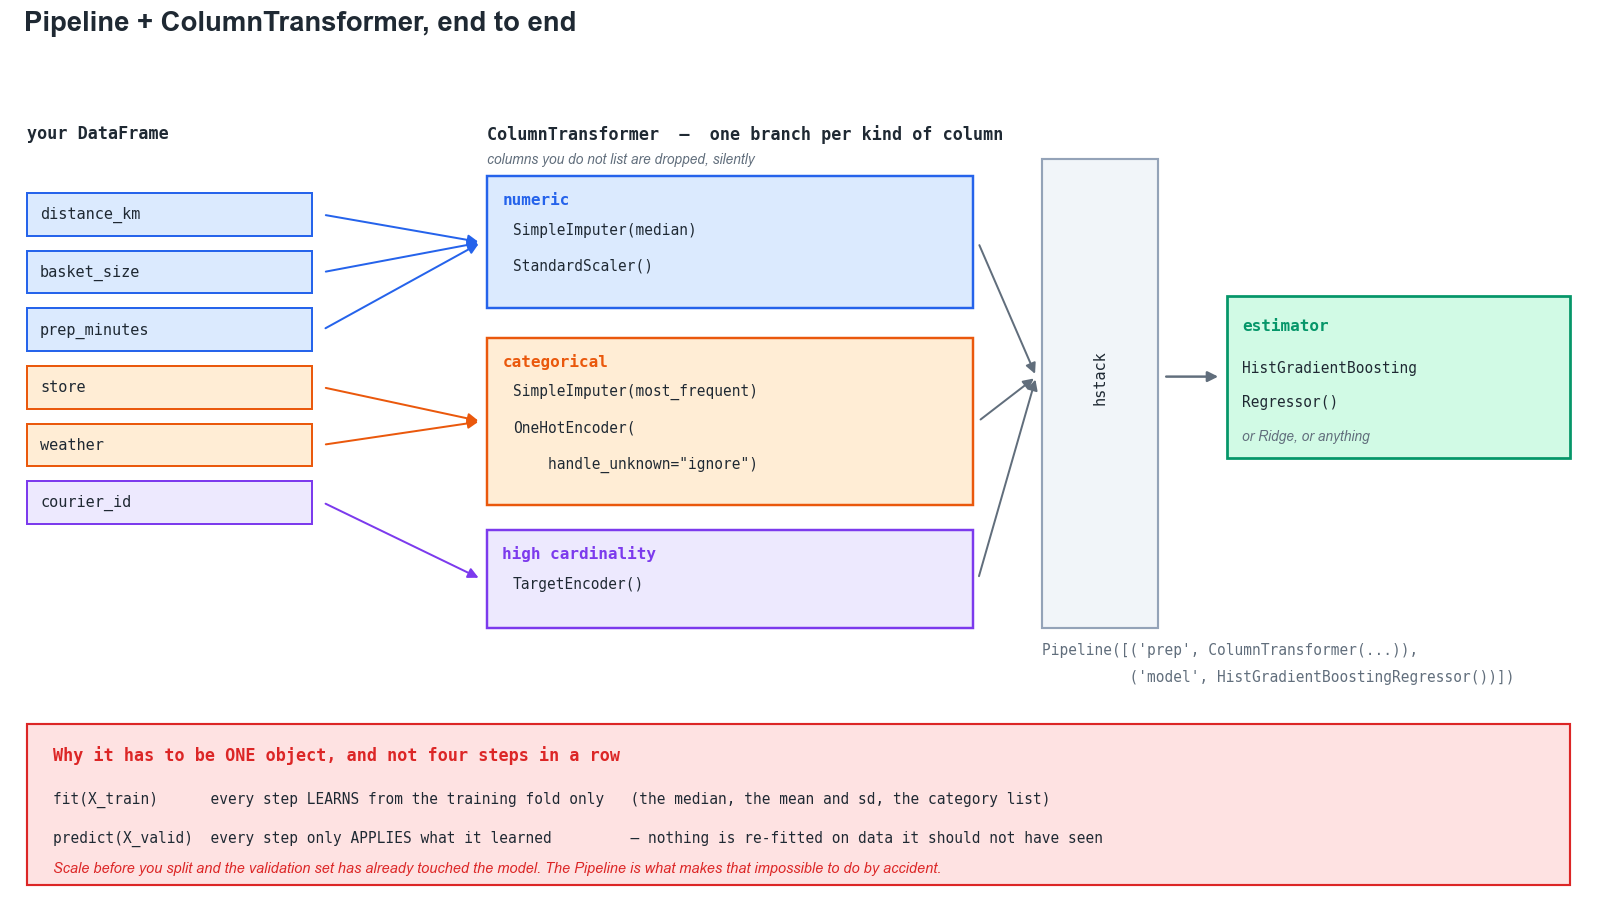

In [4]:
pipeline_anatomy();   # also assets/pipeline_anatomy.png

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

NUMERIC = ["distance_km", "prep_minutes", "basket_size", "basket_value_toman"]
CATEGORICAL = ["store", "courier_type", "weather"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore",
                                               sparse_output=False))]), CATEGORICAL),
])
# Columns you do not list are dropped. That is the safe default: a column has
# to be named before it can get anywhere near the model.

# fit_transform on a slice, just to see the shape it produces
out = preprocess.fit_transform(deliveries[NUMERIC + CATEGORICAL])
print(f"{len(NUMERIC + CATEGORICAL)} columns in -> {out.shape[1]} columns out")
preprocess

7 columns in -> 13 columns out


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['distance_km', 'prep_minutes', 'basket_size',
                                  'basket_value_toman']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['store', 'courier_type', 'weather'])])

That display is worth clicking through in your own notebook — sklearn renders
the whole structure interactively, and it is the fastest way to confirm you
built what you meant to build.

---

## 4. Features: the part that actually moves the number

Preprocessing makes columns usable. **Feature engineering creates columns that
were not there.** On tabular problems it is almost always where the gains are,
and it is the part no library can do for you, because it requires knowing what
the data means.

Most industrial tabular problems are a **panel**: one row per entity per time
period. Sales per product per day, sessions per user per day, readings per
sensor per hour. For that shape there is a standard vocabulary of feature
families, and knowing it turns "think of some features" into "work down a
list".

This is the taxonomy from a real demand-forecasting project. Notebook 05 builds
every one of these on live data.

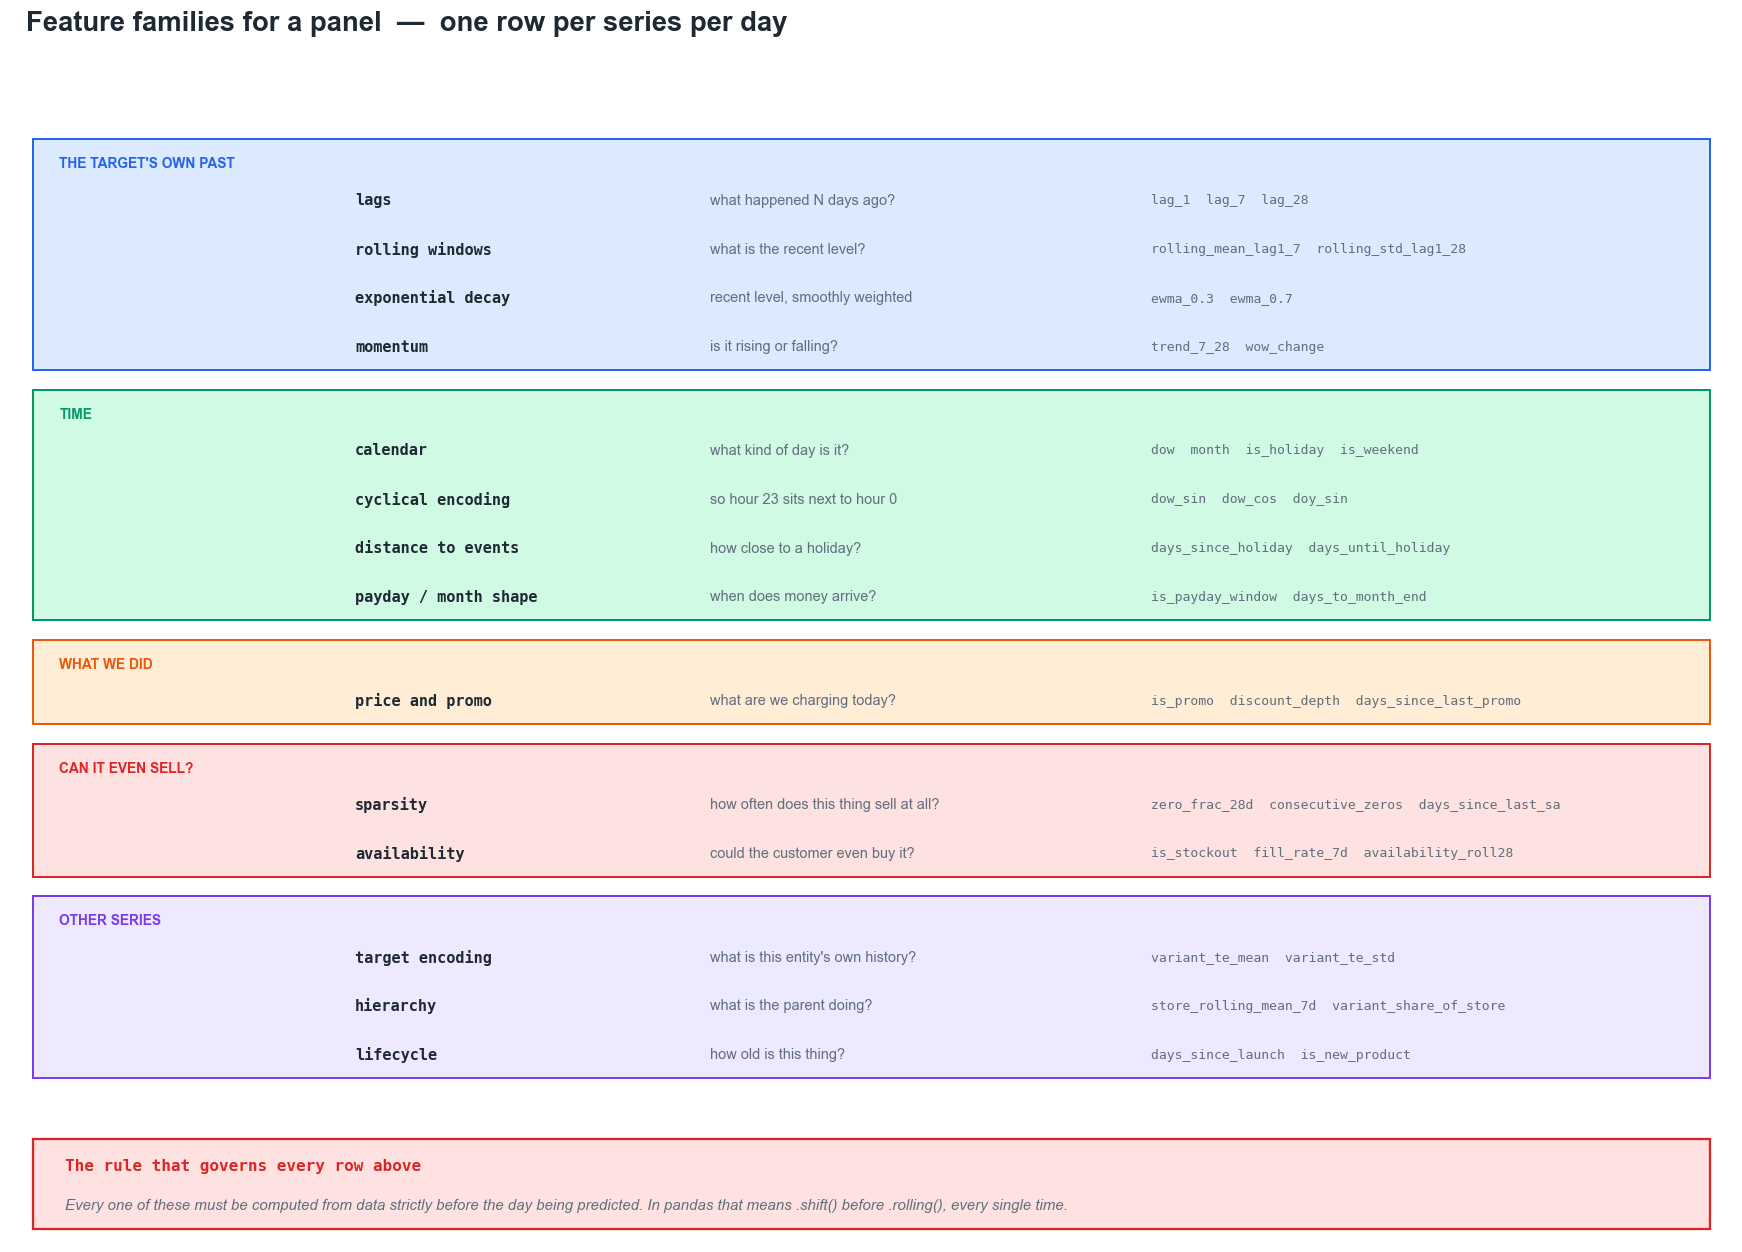

In [6]:
feature_families();   # also assets/feature_families.png

Two things about that sheet.

**The families are ordered by how much they usually pay.** The target's own
past is nearly always the strongest signal — what a thing did yesterday and
last week is the best predictor of what it does tomorrow. Calendar comes next.
The rest matter enormously in specific problems and barely at all in others.

**The red band at the bottom is the rule that makes or breaks the project.**
Every feature must be computed from data strictly before the day being
predicted. In pandas that means `.shift()` *before* `.rolling()`, every single
time:

```python
df["roll_7"] = df.groupby("id")["y"].rolling(7).mean()          # LEAKS: includes today
df["roll_7"] = df.groupby("id")["y"].shift(1).rolling(7).mean() # correct
```

The first line includes today's target in today's feature. It will give you a
beautiful validation score and a useless model. It is the single most common
mistake in time-series feature engineering, and it is one character wide.

In [7]:
# The one-character mistake, made visible on a toy series.
toy = pd.DataFrame({
    "day": range(1, 8),
    "sales": [10.0, 12, 9, 30, 11, 13, 12],   # day 4 is a spike
})

# WRONG: the window includes today, so the feature already knows about the spike
toy["mean_3_leaky"] = toy["sales"].rolling(3, min_periods=1).mean()
# RIGHT: shift first, so the window can only see days strictly before today
toy["mean_3_safe"] = toy["sales"].shift(1).rolling(3, min_periods=1).mean()

print(toy.round(2).to_string(index=False))
print("\nOn day 4 the leaky feature has already moved to 17.0 -- it saw the spike")
print("it is supposed to help predict. The safe one still says 10.3.")

 day  sales  mean_3_leaky  mean_3_safe
   1   10.0         10.00          NaN
   2   12.0         11.00        10.00
   3    9.0         10.33        11.00
   4   30.0         17.00        10.33
   5   11.0         16.67        17.00
   6   13.0         18.00        16.67
   7   12.0         12.00        18.00

On day 4 the leaky feature has already moved to 17.0 -- it saw the spike
it is supposed to help predict. The safe one still says 10.3.


---

## Where this goes next

You now have the vocabulary: a menu of preprocessing steps, a container that
applies them safely, and a taxonomy of features to build.

Notebook 05 takes all of it to a real problem — forecasting demand for
thousands of products in a dark store — where the data is 90% zeros, the
features have to be built with that `.shift()` discipline across 1.8 million
rows, and one innocent-looking decision about how to construct the table
created a leak that took a while to find.